# Koji build lag: s390x

Measured from a `koji-lag` SQLite store. Each section states what it shows; the
reading of it is left to be written.

## Setup

In [1]:
import os, sqlite3, statistics, datetime, collections
import pandas as pd
import matplotlib.pyplot as plt

# Point at a store: $KOJI_LAG_STORE, else a sibling checkout of sandogasa.
STORE = os.environ.get("KOJI_LAG_STORE") or os.path.expanduser(
    "~/src/github/slopfest/sandogasa/scratch/lag.sqlite")
if not os.path.exists(STORE):
    raise SystemExit(f"no store at {STORE}; set KOJI_LAG_STORE")
DB = sqlite3.connect(f"file:{STORE}?mode=ro", uri=True)
INSTANCE = "fedora"

def q(sql, *params):
    return pd.read_sql_query(sql, DB, params=params)

def ts(date):
    return datetime.datetime.strptime(date, "%Y-%m-%d").replace(
        tzinfo=datetime.UTC).timestamp()

def pct(xs, p):
    xs = sorted(xs)
    return xs[min(int(p * len(xs)), len(xs) - 1)] if xs else float("nan")

# Median and p90 together, always — a lone median hides the tail that drives
# capacity.
def summary(xs, unit=60.0):
    import math
    xs = [x for x in xs
          if x is not None and not (isinstance(x, float) and math.isnan(x))]
    if not xs:
        return {}
    return {"n": len(xs), "median": statistics.median(xs) / unit,
            "p90": pct(xs, 0.9) / unit, "mean": statistics.mean(xs) / unit,
            "max": max(xs) / unit}

# Build classes. Classify on target, never on the submitting account: ELN's
# sync account was renamed mid-history and koschei's carries a datacentre
# name that changed.
CLASS_SQL = """
  CASE WHEN b.target LIKE 'eln%' OR b.owner = 'eln-buildsync'
            OR b.owner LIKE 'distrobuildsync-eln%' THEN 'eln'
       WHEN b.target LIKE '%-rebuild' OR b.owner = 'releng' THEN 'mass-rebuild'
       WHEN b.owner LIKE 'koschei/%' THEN 'koschei'
       WHEN b.owner IN ('packit', 'zuul') THEN 'ci'
       WHEN b.scratch = 1 THEN 'hand-scratch'
       ELSE 'official' END
"""
REBUILD = "(b.target LIKE '%-rebuild' OR b.owner = 'releng')"
print(f"store: {STORE}  ({os.path.getsize(STORE) / 2**30:.1f} GiB)")

store: /home/michel/src/github/slopfest/sandogasa/scratch/lag.sqlite  (2.4 GiB)


## What the store covers

,first,last,spans
0,2024-12-24,2026-08-20,2


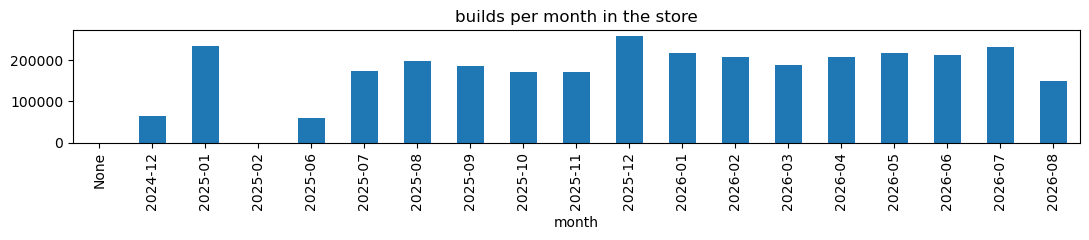

In [2]:
cov = q("""SELECT date(min(from_ts),'unixepoch') AS first,
                  date(max(to_ts),'unixepoch') AS last,
                  count(*) AS spans FROM listed WHERE instance = ?""", INSTANCE)
months = q("""SELECT strftime('%Y-%m', completion_ts, 'unixepoch') AS month,
                     count(*) AS builds
              FROM builds WHERE instance = ? GROUP BY 1 ORDER BY 1""", INSTANCE)
display(cov)
months.set_index("month").plot.bar(figsize=(11, 2.5), legend=False,
                                   title="builds per month in the store")
plt.tight_layout(); plt.show()

## Mass rebuild windows

Dated from who submitted each day, not from the schedule — the two disagree.

In [3]:
days = q(f"""
  SELECT date(completion_ts,'unixepoch') AS day, count(*) AS builds,
         sum(CASE WHEN {REBUILD.replace('b.','')} THEN 1 ELSE 0 END) AS releng
  FROM builds b WHERE instance = ? GROUP BY 1 HAVING builds >= 500 ORDER BY 1
""", INSTANCE)
days["share"] = days.releng / days.builds

# A day is part of a rebuild when releng holds a tenth of it; the two
# populations sit either side of an empty range, so the threshold is not
# sensitive. Runs of one day are targeted rebuilds, not mass ones.
hot = days[days.share >= 0.10].day.tolist()
windows, run = [], []
for d in hot:
    if run and (datetime.date.fromisoformat(d)
                - datetime.date.fromisoformat(run[-1])).days > 1:
        if len(run) >= 2:
            windows.append((run[0], run[-1]))
        run = []
    run.append(d)
if len(run) >= 2:
    windows.append((run[0], run[-1]))
print("detected rebuild windows:", windows)

detected rebuild windows: [('2025-01-16', '2025-01-19'), ('2025-07-23', '2025-07-26'), ('2026-01-16', '2026-01-19'), ('2026-07-15', '2026-07-18')]


## s390x queue wait per rebuild, by class of build

The rebuild's own tasks against everyone else's.

In [4]:
rows = []
for a, b in windows:
    per = q(f"""
      SELECT {CLASS_SQL} AS cls, t.start_ts - t.create_ts AS wait
      FROM tasks t JOIN builds b
        ON b.instance = t.instance AND b.task_id = t.parent
      WHERE t.instance = ? AND t.arch = 's390x' AND t.method = 'buildArch'
        AND t.start_ts IS NOT NULL
        AND t.create_ts >= ? AND t.create_ts < ?
    """, INSTANCE, ts(a), ts(b) + 86400)
    for cls, grp in per.groupby("cls"):
        s = summary(grp.wait.tolist(), 3600.0)
        if s.get("n", 0) >= 30:
            rows.append(dict(window=a, cls=cls, **s,
                             over_1h=100 * (grp.wait > 3600).mean()))
wait = pd.DataFrame(rows).round(2)
display(wait.pivot(index="window", columns="cls", values="median"))
display(wait)

cls,ci,eln,hand-scratch,koschei,mass-rebuild,official
window,,,,,,
2025-01-16,0.02,0.01,0.02,0.01,0.01,0.01
2025-07-23,0.02,0.02,0.06,0.01,2.00,0.02
2026-01-16,0.02,8.04,0.03,NaN,4.22,0.02
2026-07-15,0.06,0.04,0.02,NaN,3.84,0.02


,window,cls,n,median,p90,mean,max,over_1h
0,2025-01-16,ci,67,0.02,1.40,0.32,3.38,13.43
1,2025-01-16,eln,87,0.01,0.04,0.06,1.46,1.15
2,2025-01-16,hand-scratch,445,0.02,0.22,0.13,5.94,4.27
3,2025-01-16,koschei,1495,0.01,0.02,0.02,4.77,0.07
4,2025-01-16,mass-rebuild,15900,0.01,0.12,0.08,56.43,1.79
5,2025-01-16,official,555,0.01,0.02,0.02,0.23,0.00
6,2025-07-23,ci,87,0.02,2.78,0.76,5.29,31.03
7,2025-07-23,eln,69,0.02,2.30,0.75,2.31,36.23
8,2025-07-23,hand-scratch,552,0.06,2.96,1.38,47.77,36.59
9,2025-07-23,koschei,405,0.01,0.02,0.59,47.31,1.48


## Service time by architecture

The control: a toolchain or package-mix change would move every architecture.

arch,aarch64,ppc64le,s390x,x86_64
window,,,,
2025-01-16,1.34,2.10,1.43,1.55
2025-07-23,1.42,2.09,2.01,1.26
2026-01-16,1.31,1.83,2.02,1.07
2026-07-15,1.44,1.93,2.23,1.21


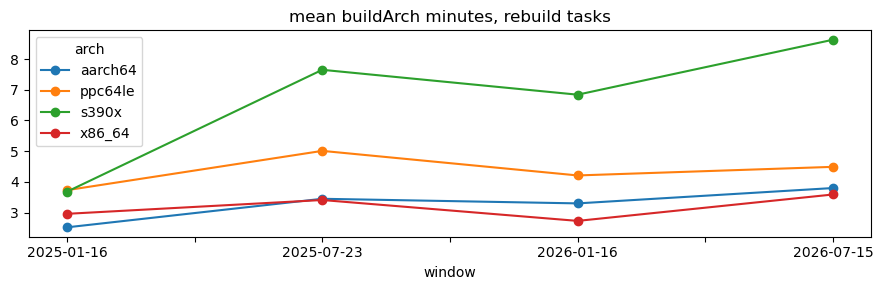

In [5]:
rows = []
for a, b in windows:
    for arch in ("x86_64", "aarch64", "ppc64le", "s390x"):
        d = q(f"""SELECT t.completion_ts - t.start_ts AS dur
                  FROM tasks t JOIN builds b
                    ON b.instance = t.instance AND b.task_id = t.parent
                  WHERE t.instance = ? AND t.arch = ? AND t.method = 'buildArch'
                    AND t.start_ts IS NOT NULL AND t.completion_ts IS NOT NULL
                    AND {REBUILD}
                    AND t.create_ts >= ? AND t.create_ts < ?""",
                INSTANCE, arch, ts(a), ts(b) + 86400)
        s = summary(d.dur.tolist())
        if s:
            rows.append(dict(window=a, arch=arch, **s))
svc = pd.DataFrame(rows).round(2)
display(svc.pivot(index="window", columns="arch", values="median"))
svc.pivot(index="window", columns="arch", values="mean").plot(
    figsize=(9, 3), marker="o", title="mean buildArch minutes, rebuild tasks")
plt.tight_layout(); plt.show()

## Builder capacity

From the hub's own `host_config` history: enabled hosts and the weight they
accept, which is what Koji schedules against.

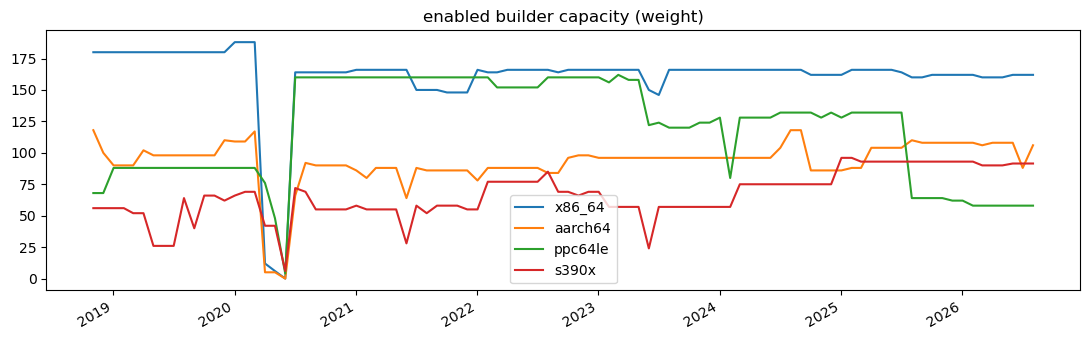

,x86_64,aarch64,ppc64le,s390x
2018-01-01 00:00:00+00:00,180.0,118.0,68.0,56.0
2019-01-01 00:00:00+00:00,180.0,90.0,88.0,56.0
2020-01-01 00:00:00+00:00,188.0,109.0,88.0,66.0
2021-01-01 00:00:00+00:00,166.0,86.0,160.0,58.0
2022-01-01 00:00:00+00:00,166.0,78.0,160.0,55.0
2023-01-01 00:00:00+00:00,166.0,96.0,160.0,69.0
2024-01-01 00:00:00+00:00,166.0,96.0,128.0,57.0
2025-01-01 00:00:00+00:00,162.0,86.0,128.0,96.0
2026-01-01 00:00:00+00:00,162.0,108.0,62.0,93.0


In [6]:
def capacity(arch, at):
    r = DB.execute("""SELECT count(*), coalesce(sum(capacity), 0.0)
        FROM host_config WHERE instance = ? AND enabled = 1
          AND create_ts <= ? AND (revoke_ts IS NULL OR revoke_ts > ?)
          AND (' ' || arches || ' ') LIKE ?""",
        (INSTANCE, at, at, f"%{arch}%")).fetchone()
    return r

first, = DB.execute("SELECT min(create_ts) FROM host_config WHERE instance = ?",
                    (INSTANCE,)).fetchone()
months = pd.date_range(datetime.datetime.fromtimestamp(first, datetime.UTC),
                       datetime.datetime.now(datetime.UTC), freq="MS", tz="UTC")
cap = pd.DataFrame({
    arch: [capacity(arch, m.timestamp())[1] for m in months]
    for arch in ("x86_64", "aarch64", "ppc64le", "s390x")}, index=months)
cap.plot(figsize=(11, 3.5), title="enabled builder capacity (weight)")
plt.tight_layout(); plt.show()
display(cap.resample("YS").first().round(0))

## Utilisation against observed wait

Offered weight over capacity, per rebuild, beside the wait actually seen.

In [7]:
rows = []
for a, b in windows:
    lo, hi = ts(a), ts(b) + 86400
    wsecs, = DB.execute("""SELECT sum(max(0, min(coalesce(completion_ts, ?2), ?2)
                                        - max(start_ts, ?1)) * coalesce(weight, 1))
        FROM tasks WHERE instance = ?3 AND arch = 's390x' AND method = 'buildArch'
          AND start_ts IS NOT NULL AND start_ts < ?2
          AND coalesce(completion_ts, ?2) >= ?1""", (lo, hi, INSTANCE)).fetchone()
    _, capw = capacity("s390x", lo + 43200)
    w = q(f"""SELECT t.start_ts - t.create_ts AS wait FROM tasks t JOIN builds b
              ON b.instance = t.instance AND b.task_id = t.parent
              WHERE t.instance = ? AND t.arch = 's390x' AND t.method = 'buildArch'
                AND t.start_ts IS NOT NULL AND {REBUILD}
                AND t.create_ts >= ? AND t.create_ts < ?""",
            INSTANCE, lo, hi)
    rows.append(dict(window=a, offered=(wsecs or 0) / (hi - lo), capacity=capw,
                     rho=(wsecs or 0) / (hi - lo) / capw if capw else float("nan"),
                     median_wait_h=statistics.median(w.wait) / 3600,
                     p90_wait_h=pct(w.wait.tolist(), 0.9) / 3600))
util = pd.DataFrame(rows).round(2)
display(util)

# What capacity would buy, at the most recent window's offered load.
offered = util.offered.iloc[-1]
here = util.capacity.iloc[-1]
guide = pd.DataFrame([
    dict(target_rho=r, capacity=round(offered / r), multiple=round(offered / r / here, 2),
         extra_hosts=round((offered / r - here) / 4.9))
    for r in (0.9, 0.8, 0.7, 0.6, 0.5)])
display(guide)

,window,offered,capacity,rho,median_wait_h,p90_wait_h
0,2025-01-16,52.25,96.0,0.54,0.01,0.12
1,2025-07-23,67.15,93.0,0.72,2.00,5.08
2,2026-01-16,73.34,93.0,0.79,4.22,7.76
3,2026-07-15,113.52,91.5,1.24,3.84,8.30


,target_rho,capacity,multiple,extra_hosts
0,0.9,126,1.38,7
1,0.8,142,1.55,10
2,0.7,162,1.77,14
3,0.6,189,2.07,20
4,0.5,227,2.48,28


## The tail

Tasks over six hours, and how much of the architecture's rebuild they take.

In [8]:
rows = []
for a, b in windows:
    d = q(f"""SELECT coalesce(b.package, t.package) AS package,
                     t.completion_ts - t.start_ts AS dur, t.state
              FROM tasks t JOIN builds b
                ON b.instance = t.instance AND b.task_id = t.parent
              WHERE t.instance = ? AND t.arch = 's390x' AND t.method = 'buildArch'
                AND t.completion_ts IS NOT NULL AND {REBUILD}
                AND t.create_ts >= ? AND t.create_ts < ?""",
            INSTANCE, ts(a), ts(b) + 86400)
    long = d[d.dur > 6 * 3600]
    # Koji task states: 2 CLOSED, 3 CANCELED, 5 FAILED.
    rows.append(dict(window=a, total_h=d.dur.sum() / 3600, over_6h=len(long),
                     over_6h_h=long.dur.sum() / 3600,
                     over_6h_share=100 * long.dur.sum() / d.dur.sum(),
                     wasted_share=100 * d[d.state.isin([3, 5])].dur.sum() / d.dur.sum()))
display(pd.DataFrame(rows).round(1))

last = windows[-1]
d = q(f"""SELECT coalesce(b.package, t.package) AS package,
                 t.completion_ts - t.start_ts AS dur, t.state
          FROM tasks t JOIN builds b ON b.instance = t.instance AND b.task_id = t.parent
          WHERE t.instance = ? AND t.arch = 's390x' AND t.method = 'buildArch'
            AND t.completion_ts IS NOT NULL AND {REBUILD}
            AND t.create_ts >= ? AND t.create_ts < ?""",
        INSTANCE, ts(last[0]), ts(last[1]) + 86400)
d["hours"] = d.dur / 3600
d["state"] = d.state.map({2: "CLOSED", 3: "CANCELED", 5: "FAILED"}).fillna(d.state)
display(d.nlargest(12, "hours")[["package", "hours", "state"]].round(1))

,window,total_h,over_6h,over_6h_h,over_6h_share,wasted_share
0,2025-01-16,974.9,4,56.3,5.8,6.8
1,2025-07-23,2009.9,24,441.2,22.0,12.5
2,2026-01-16,1444.0,11,196.7,13.6,9.1
3,2026-07-15,1818.8,26,433.3,23.8,12.5


,package,hours,state
13334,libredwg,56.1,FAILED
13335,libunwind,56.0,FAILED
12172,gnulib,52.0,CANCELED
13332,m4,50.2,CANCELED
7147,gcc,37.5,CLOSED
6640,llvm,14.2,CLOSED
13333,vtk,14.2,CLOSED
3999,cross-gcc,12.4,CLOSED
4011,ceph,11.9,CLOSED
10501,python-graph-tool,11.3,CLOSED


## Where the slowdown falls, by toolchain

Same package in both windows, so composition cannot affect the ratio. Needs a
checkout of the spec files; skipped if absent.

,other,c++,rust,c,python
arch,,,,,
s390x,1.30,1.53,1.16,1.40,1.35
x86_64,0.78,0.79,0.69,0.81,0.74
aarch64,1.08,1.13,0.94,1.12,1.05
ppc64le,0.89,0.96,0.73,0.93,0.91


arch
s390x      1.32
x86_64     1.14
aarch64    1.20
ppc64le    1.32
Name: c++ / rust, dtype: float64

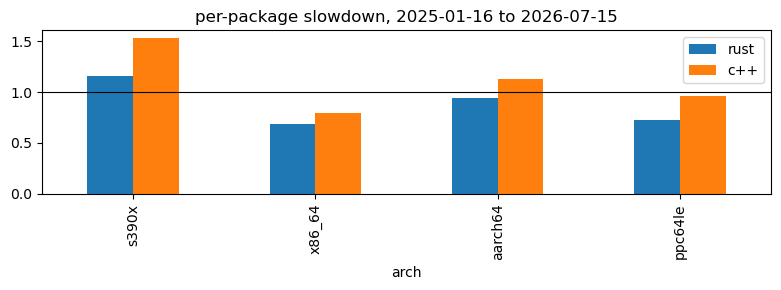

In [9]:
import glob, re
SPECS = os.environ.get("FEDORA_SPECS") or os.path.expanduser("~/src/fedora/rpm-specs")

def toolchains(path):
    out = {}
    for f in glob.glob(f"{path}/*.spec"):
        txt = open(f, errors="replace").read()
        br = " ".join(re.findall(r"^BuildRequires:\s*(.+)$", txt, re.M)).lower()
        if re.search(r"rust-packaging|%cargo_build|\bcargo\b", txt):
            c = "rust"
        # No trailing \b after ++ : it cannot match at end of line.
        elif re.search(r"gcc-c\+\+|clang\+\+|libstdc\+\+-devel", br):
            c = "c++"
        elif re.search(r"\bgcc\b|\bclang\b", br):
            c = "c"
        elif re.search(r"python3?-devel|pyproject-rpm-macros", br):
            c = "python"
        else:
            c = "other"
        out[os.path.basename(f)[:-5]] = c
    return out

def durations(arch, a, b):
    d = q(f"""SELECT coalesce(b.package, t.package) AS package,
                     t.completion_ts - t.start_ts AS dur
              FROM tasks t JOIN builds b
                ON b.instance = t.instance AND b.task_id = t.parent
              WHERE t.instance = ? AND t.arch = ? AND t.method = 'buildArch'
                AND t.completion_ts IS NOT NULL AND t.state = 2 AND {REBUILD}
                AND t.create_ts >= ? AND t.create_ts < ?""",
            INSTANCE, arch, ts(a), ts(b) + 86400)
    return dict(zip(d.package, d.dur))

if not os.path.isdir(SPECS):
    print(f"no specs at {SPECS}; set FEDORA_SPECS to enable this section")
elif len(windows) < 2:
    print("needs two rebuild windows to compare")
else:
    CLS = toolchains(SPECS)
    first_w, last_w = windows[0], windows[-1]
    rows = []
    for arch in ("s390x", "x86_64", "aarch64", "ppc64le"):
        a, z = durations(arch, *first_w), durations(arch, *last_w)
        buck = collections.defaultdict(list)
        for p in set(a) & set(z):
            if a[p] > 30:      # sub-30s builds are buildroot overhead, not work
                buck[CLS.get(p, "other")].append(z[p] / a[p])
        row = {"arch": arch}
        for k, v in buck.items():
            if len(v) >= 25:
                row[k] = statistics.median(v)
        rows.append(row)
    paired = pd.DataFrame(rows).set_index("arch").round(2)
    display(paired)
    if {"c++", "rust"} <= set(paired.columns):
        # Rust does not consume Fedora's C flags, so c++/rust isolates the
        # compile-specific cost from whatever the platform did.
        display((paired["c++"] / paired["rust"]).round(2).rename("c++ / rust"))
        paired[["rust", "c++"]].plot.bar(
            figsize=(8, 3), title=f"per-package slowdown, {first_w[0]} to {last_w[0]}")
        plt.axhline(1.0, color="k", lw=0.8); plt.tight_layout(); plt.show()

## Single-architecture stalls

Days one architecture fell an order of magnitude behind the others, labelled by
whether its builders were busy at the time.

In [10]:
# A select alias cannot be used inside an expression in the same list, hence
# the CTE: `day` has to exist before the running-time integral can clamp to it.
day = q("""WITH d AS (
             SELECT cast(create_ts / 86400 AS INTEGER) * 86400 AS day, arch,
                    create_ts, start_ts, completion_ts
             FROM tasks WHERE instance = ? AND method = 'buildArch')
           SELECT day, arch, count(*) AS created,
                  sum(CASE WHEN start_ts IS NOT NULL THEN 1 ELSE 0 END) AS started,
                  avg(CASE WHEN start_ts IS NOT NULL
                           THEN start_ts - create_ts END) AS wait,
                  sum(CASE WHEN start_ts IS NOT NULL
                      THEN max(0, min(coalesce(completion_ts, day + 86400),
                                      day + 86400) - max(start_ts, day))
                      ELSE 0 END) / 86400.0 AS running
           FROM d GROUP BY 1, 2 HAVING created >= 50 AND wait IS NOT NULL""",
        INSTANCE)
base = day.groupby("arch").running.median()

out = []
for d, grp in day.groupby("day"):
    for _, r in grp.iterrows():
        peers = grp[grp.arch != r.arch].wait
        if len(peers) == 0 or r.wait < 3600:
            continue
        if r.wait >= 10 * peers.median():
            out.append(dict(day=datetime.datetime.fromtimestamp(d, datetime.UTC).date(),
                            arch=r.arch, wait_h=r.wait / 3600,
                            peers_m=peers.median() / 60, running=r.running,
                            ordinary=base[r.arch], never_ran=r.created - r.started))
stalls = pd.DataFrame(out)
# Busier than usual and still behind is congestion; quieter than usual is an
# outage — capacity that existed and was not working.
stalls["verdict"] = ["outage" if r.running < r.ordinary else "congestion"
                     for _, r in stalls.iterrows()]
display(stalls.round(1).sort_values("day"))

,day,arch,wait_h,peers_m,running,ordinary,never_ran,verdict
0,2025-07-23,s390x,1.2,3.9,14.4,5.3,102,congestion
1,2025-07-24,s390x,3.0,1.8,27.4,5.3,579,congestion
2,2025-07-25,s390x,3.0,2.7,23.9,5.3,172,congestion
3,2025-07-26,s390x,1.5,4.3,17.4,5.3,140,congestion
4,2025-08-13,s390x,1.6,0.7,10.4,5.3,28,congestion
5,2025-08-15,s390x,5.0,1.7,18.9,5.3,32,congestion
6,2025-08-16,s390x,6.1,1.8,13.1,5.3,105,congestion
7,2025-08-20,s390x,2.0,0.7,8.4,5.3,19,congestion
8,2025-08-21,s390x,3.0,0.8,3.0,5.3,18,outage
9,2025-08-26,s390x,2.5,0.7,8.0,5.3,7,congestion
